# 0. Imports and Environment Setup #

In [17]:
import numpy as np
import sys
import os
from typing import Optional, List, Callable, Union

# Add parent directory to path for local module imports
sys.path.append('../')
import linear_system_solvers as lss
from visualization import Plotter, PlotParams

# Configure numpy display options for readability
np.set_printoptions(precision=4, suppress=True)

# 1. Linear System Solvers #

In [ ]:
def solve_tdma(a_vec, b_vec, c_vec, d_vec):
    """
    Tridiagonal Matrix Algorithm (TDMA / Thomas Algorithm).
    Solves a system of linear equations with a tridiagonal matrix.

    Parameters
    ----------
    - a_vec (np.ndarray): Lower diagonal (a[0] is unused).
    - b_vec (np.ndarray): Main diagonal.
    - c_vec (np.ndarray): Upper diagonal (c[n-1] is unused).
    - d_vec (np.ndarray): Right-hand side vector.

    Returns
    -------
    - x_vec (np.ndarray): Solution vector.

    Notes
    -----
    • *Mathematical foundation*
    System:
    b₀x₀ + c₀x₁ = d₀
    aᵢxᵢ₋₁ + bᵢxᵢ + cᵢxᵢ₊₁ = dᵢ, i = 1..n-2
    aₙ₋₁xₙ₋₂ + bₙ₋₁xₙ₋₁ = dₙ₋₁

    • *Algorithm workflow*
    1. **Forward Elimination**: Pᵢ = -cᵢ/(bᵢ + aᵢPᵢ₋₁), Qᵢ = (dᵢ - aᵢQᵢ₋₁)/(bᵢ + aᵢPᵢ₋₁)
    2. **Backward Substitution**: xᵢ = Pᵢxᵢ₊₁ + Qᵢ
    """
    n = len(d_vec)
    
    p_vec = np.zeros(n)
    q_vec = np.zeros(n)
    x_vec = np.zeros(n)
    
    # --- Forward Elimination ---
    p_vec[0] = -c_vec[0] / b_vec[0]
    q_vec[0] = d_vec[0] / b_vec[0]
    
    for i in range(1, n):
        denom = b_vec[i] + a_vec[i] * p_vec[i-1]
        if i < n - 1:
            p_vec[i] = -c_vec[i] / denom
        q_vec[i] = (d_vec[i] - a_vec[i] * q_vec[i-1]) / denom
        
    # --- Backward Substitution ---
    x_vec[n-1] = q_vec[n-1]
    for i in range(n-2, -1, -1):
        x_vec[i] = p_vec[i] * x_vec[i+1] + q_vec[i]
        
    return x_vec

# 2. Interpolation and Approximation Methods #

In [ ]:
def newton_interpolation(x_nodes_vec, y_nodes_vec):
    """
    Computes coefficients for Newton polynomial interpolation.

    Parameters
    ----------
    - x_nodes_vec (np.ndarray): Interpolation nodes.
    - y_nodes_vec (np.ndarray): Function values.

    Returns
    -------
    - coeffs_vec (np.ndarray): Divided difference coefficients.

    Notes
    -----
    • *Mathematical foundation*
    Pₙ(x) = f[x₀] + ∑ f[x₀, ..., xₖ] ∏(x - xⱼ)

    • *Algorithm workflow*
    1. Initialize coefficients with y values.
    2. Compute divided differences iteratively:
       f[xᵢ, ..., xᵢ₊ⱼ] = (f[xᵢ₊₁, ..., xᵢ₊ⱼ] - f[xᵢ, ..., xᵢ₊ⱼ₋₁]) / (xᵢ₊ⱼ - xᵢ)
    """
    n = len(x_nodes_vec)
    coeffs_vec = np.copy(y_nodes_vec).astype(float)
    
    # --- Compute Divided Differences ---
    for j in range(1, n):
        # Update coefficients in-place using array slicing
        # coeffs_vec[j:] corresponds to the current order differences
        # coeffs_vec[j-1:-1] corresponds to the previous order differences
        coeffs_vec[j:] = (coeffs_vec[j:] - coeffs_vec[j-1:-1]) / (x_nodes_vec[j:] - x_nodes_vec[:-j])
            
    return coeffs_vec

In [20]:
def evaluate_newton(coeffs_vec, x_nodes_vec, x_target_vec):
    """
    Evaluates the Newton polynomial at specified points.

    Parameters
    ----------
    - coeffs_vec (np.ndarray): Divided difference coefficients.
    - x_nodes_vec (np.ndarray): Interpolation nodes.
    - x_target_vec (np.ndarray): Target points for evaluation.

    Returns
    -------
    - y_target_vec (np.ndarray): Evaluated values.

    Notes
    -----
    Uses Horner's method for efficient evaluation:
    P(x) = c_0 + (x-x_0)(c_1 + (x-x_1)(...))
    """
    n = len(coeffs_vec)
    
    # --- Horner's Method ---
    result = np.full_like(x_target_vec, coeffs_vec[n-1], dtype=float)
    
    for j in range(n-2, -1, -1):
        result = result * (x_target_vec - x_nodes_vec[j]) + coeffs_vec[j]
        
    return result

In [ ]:
def cubic_spline_interpolation(x_nodes_vec, y_nodes_vec):
    """
    Constructs a cubic spline with natural boundary conditions.

    Parameters
    ----------
    - x_nodes_vec (np.ndarray): Ordered interpolation nodes.
    - y_nodes_vec (np.ndarray): Function values.

    Returns
    -------
    - spline_coeffs_arr (np.ndarray): Coefficients matrix (N-1, 4).
      Rows correspond to intervals, columns to [a, b, c, d].

    Notes
    -----
    • *Algorithm workflow*
    1. Compute step sizes hᵢ.
    2. Form tridiagonal system for moments Mᵢ = S''(xᵢ).
    3. Solve for M using TDMA.
    4. Compute coefficients aᵢ, bᵢ, cᵢ, dᵢ from M and y.
    """
    n = len(x_nodes_vec)
    if n < 3:
        raise ValueError("At least 3 points are required.")
        
    h_vec = np.diff(x_nodes_vec)
    
    # --- Construct Tridiagonal System ---
    # Lower diagonal (a), Main diagonal (b), Upper diagonal (c)
    a_sys = h_vec[:-1]
    b_sys = 2 * (h_vec[:-1] + h_vec[1:])
    c_sys = h_vec[1:]
    
    # Right-hand side (d) based on second-order divided differences
    diff_right = (y_nodes_vec[2:] - y_nodes_vec[1:-1]) / h_vec[1:]
    diff_left = (y_nodes_vec[1:-1] - y_nodes_vec[:-2]) / h_vec[:-1]
    d_sys = 6 * (diff_right - diff_left)
    
    # --- Solve for Moments ---
    m_inner = solve_tdma(a_sys, b_sys, c_sys, d_sys)
    
    m_vec = np.zeros(n)
    m_vec[1:-1] = m_inner # Natural boundary conditions: M_0 = M_n = 0
    
    # --- Compute Polynomial Coefficients ---
    # S_i(x) = a_i + b_i(dx) + c_i(dx)^2 + d_i(dx)^3
    a = y_nodes_vec[:-1]
    c = m_vec[:-1] / 2
    b = (y_nodes_vec[1:] - y_nodes_vec[:-1]) / h_vec - h_vec * (2*m_vec[:-1] + m_vec[1:]) / 6
    d = (m_vec[1:] - m_vec[:-1]) / (6 * h_vec)
    
    spline_coeffs_arr = np.column_stack((a, b, c, d))
        
    return spline_coeffs_arr

In [22]:
def evaluate_spline(spline_coeffs_arr, x_nodes_vec, x_target_vec):
    """
    Evaluates the cubic spline at specified points.

    Parameters
    ----------
    - spline_coeffs_arr (np.ndarray): Spline coefficients.
    - x_nodes_vec (np.ndarray): Interpolation nodes.
    - x_target_vec (np.ndarray): Target points.

    Returns
    -------
    - y_target_vec (np.ndarray): Evaluated values.

    Notes
    -----
    Finds the appropriate interval for each target point and evaluates the corresponding cubic polynomial.
    """
    n_intervals = len(spline_coeffs_arr)
    
    # --- Find Intervals ---
    indices = np.searchsorted(x_nodes_vec, x_target_vec, side='right') - 1
    indices = np.clip(indices, 0, n_intervals - 1)
    
    # --- Evaluate Polynomials ---
    coeffs = spline_coeffs_arr[indices]
    dx = x_target_vec - x_nodes_vec[indices]
    
    y_target_vec = coeffs[:, 0] + coeffs[:, 1] * dx + coeffs[:, 2] * dx**2 + coeffs[:, 3] * dx**3
    
    return y_target_vec

In [ ]:
def generalized_linear_least_squares(x_nodes_vec, y_nodes_vec, basis_funcs: List[Callable]):
    """
    Approximates data using Generalized Linear Least Squares (GLLS).

    Parameters
    ----------
    - x_nodes_vec (np.ndarray): Data points.
    - y_nodes_vec (np.ndarray): Data values.
    - basis_funcs (List[Callable]): Basis functions φⱼ(x).

    Returns
    -------
    - coeffs_vec (np.ndarray): Optimal coefficients c.

    Notes
    -----
    • *Mathematical foundation*
    Minimize E = ||y - Fc||².
    Normal equations: (FᵀF)c = Fᵀy.

    • *Algorithm workflow*
    1. Construct Design Matrix F: Fᵢⱼ = φⱼ(xᵢ).
    2. Solve normal equations using Gaussian elimination.
    """
    m = len(basis_funcs)
    n = len(x_nodes_vec)
    
    # --- Construct Design Matrix ---
    f_matrix = np.zeros((n, m))
    for j in range(m):
        f_matrix[:, j] = basis_funcs[j](x_nodes_vec)
        
    # --- Solve Normal Equations ---
    ft_f = f_matrix.T @ f_matrix
    ft_y = f_matrix.T @ y_nodes_vec
    
    coeffs_vec = lss.solve_gauss(ft_f, ft_y)
    
    return coeffs_vec

In [24]:
def evaluate_glls(coeffs_vec, basis_funcs, x_target_vec):
    """
    Evaluates the GLLS approximation.

    Parameters
    ----------
    - coeffs_vec (np.ndarray): Basis coefficients.
    - basis_funcs (List[Callable]): Basis functions.
    - x_target_vec (np.ndarray): Target points.

    Returns
    -------
    - y_target_vec (np.ndarray): Evaluated values.
    """
    y_target_vec = np.zeros_like(x_target_vec, dtype=float)
    for j, func in enumerate(basis_funcs):
        y_target_vec += coeffs_vec[j] * func(x_target_vec)
    return y_target_vec

# 3. Verification (Toy Example) #

Newton Interpolation Error (Max Abs): 1.0658e-14
Cubic Spline Error (Max Abs): 3.9160e-01
GLLS (Quadratic) Error (Max Abs): 0.0000e+00
Plot saved to: toy_example_verification.pdf


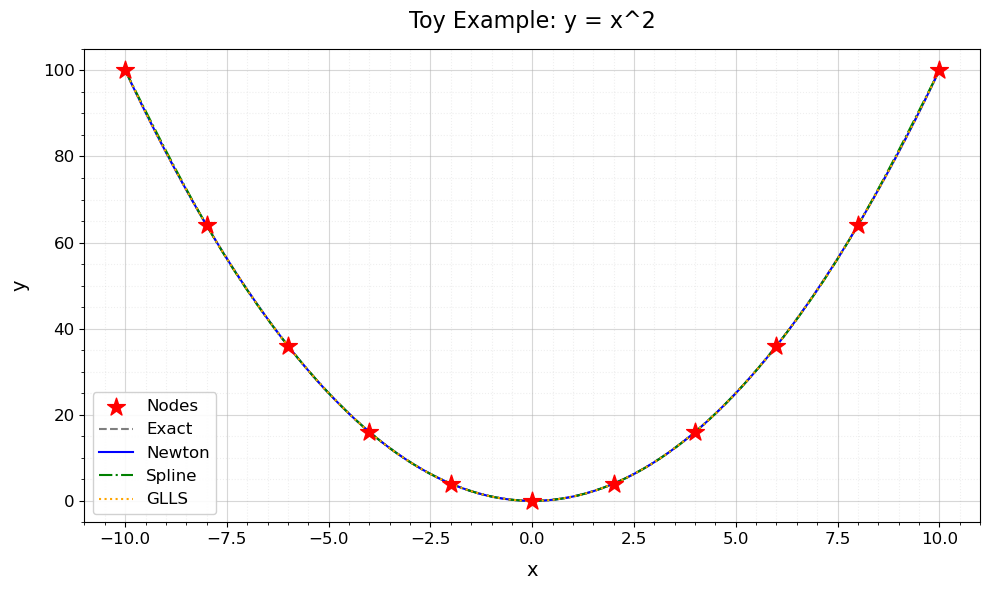

In [25]:
x_toy = np.linspace(-10, 10, 11)
y_toy = x_toy**2
x_toy_dense = np.linspace(-10, 10, 100)
y_toy_exact = x_toy_dense**2

# --- Newton ---
newton_coeffs = newton_interpolation(x_toy, y_toy)
y_toy_newton = evaluate_newton(newton_coeffs, x_toy, x_toy_dense)
err_newton = np.max(np.abs(y_toy_newton - y_toy_exact))
print(f"Newton Interpolation Error (Max Abs): {err_newton:.4e}")

# --- Spline ---
spline_coeffs = cubic_spline_interpolation(x_toy, y_toy)
y_toy_spline = evaluate_spline(spline_coeffs, x_toy, x_toy_dense)
err_spline = np.max(np.abs(y_toy_spline - y_toy_exact))
print(f"Cubic Spline Error (Max Abs): {err_spline:.4e}")

# --- GLLS (Quadratic Basis) ---
basis_quad = [lambda x: np.ones_like(x), lambda x: x, lambda x: x**2]
glls_coeffs = generalized_linear_least_squares(x_toy, y_toy, basis_quad)
y_toy_glls = evaluate_glls(glls_coeffs, basis_quad, x_toy_dense)
err_glls = np.max(np.abs(y_toy_glls - y_toy_exact))
print(f"GLLS (Quadratic) Error (Max Abs): {err_glls:.4e}")

# --- Visualization ---
plotter_toy = Plotter(title="Toy Example: y = x^2", xlabel="x", ylabel="y")
plotter_toy.add_scatter(x_toy, y_toy, PlotParams(color="red", label="Nodes", markersize=6))
plotter_toy.add_plot(x_toy_dense, y_toy_exact, PlotParams(color="black", linestyle="--", label="Exact", alpha=0.5))
plotter_toy.add_plot(x_toy_dense, y_toy_newton, PlotParams(color="blue", label="Newton"))
plotter_toy.add_plot(x_toy_dense, y_toy_spline, PlotParams(color="green", linestyle="-.", label="Spline"))
plotter_toy.add_plot(x_toy_dense, y_toy_glls, PlotParams(color="orange", linestyle=":", label="GLLS"))
plotter_toy.finalize_and_show("toy_example_verification.pdf")

# 4. Helper Function for Analysis #

In [ ]:
def analyze_country(name, years_vec, pop_vec, target_years, actual_values=None):
    """
    Performs interpolation and extrapolation for a specific country.
    """
    print(f"\n" + "="*60)
    print(f"ANALYSIS: {name}")
    print("="*60)
    
    # Dense grid for plotting (from min target year to max target year)
    min_year = min(np.min(years_vec), np.min(target_years))
    max_year = max(np.max(years_vec), np.max(target_years))
    years_dense = np.linspace(min_year, max_year, 200)
    
    # --- 1. Newton ---
    newton_coeffs = newton_interpolation(years_vec, pop_vec)
    pop_newton_dense = evaluate_newton(newton_coeffs, years_vec, years_dense)
    pop_targets_newton = evaluate_newton(newton_coeffs, years_vec, target_years)
    
    # --- 2. Spline ---
    spline_coeffs = cubic_spline_interpolation(years_vec, pop_vec)
    pop_spline_dense = evaluate_spline(spline_coeffs, years_vec, years_dense)
    pop_targets_spline = evaluate_spline(spline_coeffs, years_vec, target_years)
    
    # --- 3. GLLS (Linear) ---
    basis_lin = [lambda x: np.ones_like(x), lambda x: x]
    glls_lin_coeffs = generalized_linear_least_squares(years_vec, pop_vec, basis_lin)
    pop_glls_lin_dense = evaluate_glls(glls_lin_coeffs, basis_lin, years_dense)
    pop_targets_glls_lin = evaluate_glls(glls_lin_coeffs, basis_lin, target_years)
    
    # --- 4. GLLS (Quadratic) ---
    # Centering around mean year for stability
    mean_year = np.mean(years_vec)
    basis_quad = [
        lambda x: np.ones_like(x), 
        lambda x: (x - mean_year), 
        lambda x: (x - mean_year)**2
    ]
    glls_quad_coeffs = generalized_linear_least_squares(years_vec, pop_vec, basis_quad)
    pop_glls_quad_dense = evaluate_glls(glls_quad_coeffs, basis_quad, years_dense)
    pop_targets_glls_quad = evaluate_glls(glls_quad_coeffs, basis_quad, target_years)
    
    # --- 5. GLLS (Cubic) ---
    basis_cubic = [
        lambda x: np.ones_like(x), 
        lambda x: (x - mean_year), 
        lambda x: (x - mean_year)**2,
        lambda x: (x - mean_year)**3
    ]
    glls_cubic_coeffs = generalized_linear_least_squares(years_vec, pop_vec, basis_cubic)
    pop_glls_cubic_dense = evaluate_glls(glls_cubic_coeffs, basis_cubic, years_dense)
    pop_targets_glls_cubic = evaluate_glls(glls_cubic_coeffs, basis_cubic, target_years)
    
    # --- Print Results ---
    for i, year in enumerate(target_years):
        print(f"\nYear {year}:")
        if actual_values and year in actual_values:
            print(f"  Actual/Projected: {actual_values[year]:.2f} mln")
        print(f"  Newton:   {pop_targets_newton[i]:.2f} mln")
        print(f"  Spline:   {pop_targets_spline[i]:.2f} mln")
        print(f"  GLLS(1):  {pop_targets_glls_lin[i]:.2f} mln")
        print(f"  GLLS(2):  {pop_targets_glls_quad[i]:.2f} mln")
        print(f"  GLLS(3):  {pop_targets_glls_cubic[i]:.2f} mln")
        
    # --- Visualization ---
    plotter = Plotter(
        title=f"{name} Population Extrapolation ({int(min_year)}-{int(max_year)})", 
        xlabel="Year", 
        ylabel="Population (mln)"
    )
    
    # Data
    plotter.add_scatter(years_vec, pop_vec, PlotParams(color="red", label="Data (2010-2020)", markersize=6))
    
    # Actual/Projected Points
    if actual_values:
        years_act = np.array(list(actual_values.keys()))
        pop_act = np.array(list(actual_values.values()))
        plotter.add_scatter(years_act, pop_act, PlotParams(color="black", marker="x", label="Reference Points", markersize=8))
        
    # Curves
    plotter.add_plot(years_dense, pop_newton_dense, PlotParams(color="blue", linestyle="--", label="Newton", alpha=0.6))
    plotter.add_plot(years_dense, pop_spline_dense, PlotParams(color="green", linestyle="-.", label="Spline", alpha=0.6))
    plotter.add_plot(years_dense, pop_glls_lin_dense, PlotParams(color="orange", label="GLLS (Lin)", alpha=0.8))
    plotter.add_plot(years_dense, pop_glls_quad_dense, PlotParams(color="purple", label="GLLS (Quad)", alpha=0.8))
    plotter.add_plot(years_dense, pop_glls_cubic_dense, PlotParams(color="brown", label="GLLS (Cubic)", alpha=0.8))
    
    # Adjust Y limits to avoid extreme polynomial values
    y_min = min(np.min(pop_vec), np.min(list(actual_values.values()) if actual_values else []))
    y_max = max(np.max(pop_vec), np.max(list(actual_values.values()) if actual_values else []))
    margin = (y_max - y_min) * 0.5
    plotter.ax.set_ylim(y_min - margin, y_max + margin)
    
    plotter.finalize_and_show(f"{name.lower()}_population.pdf")

# 5. China Analysis #


ANALYSIS: China

Year 1995.0:
  Actual/Projected: 1204.86 mln
  Newton:   289017228.80 mln
  Spline:   3671.93 mln
  GLLS(1):  1233.41 mln
  GLLS(2):  1223.55 mln
  GLLS(3):  1024.43 mln

Year 2025.0:
  Actual/Projected: 1424.38 mln
  Newton:   163011.80 mln
  Spline:   1238.77 mln
  GLLS(1):  1445.35 mln
  GLLS(2):  1443.07 mln
  GLLS(3):  1464.48 mln
Plot saved to: china_population.pdf


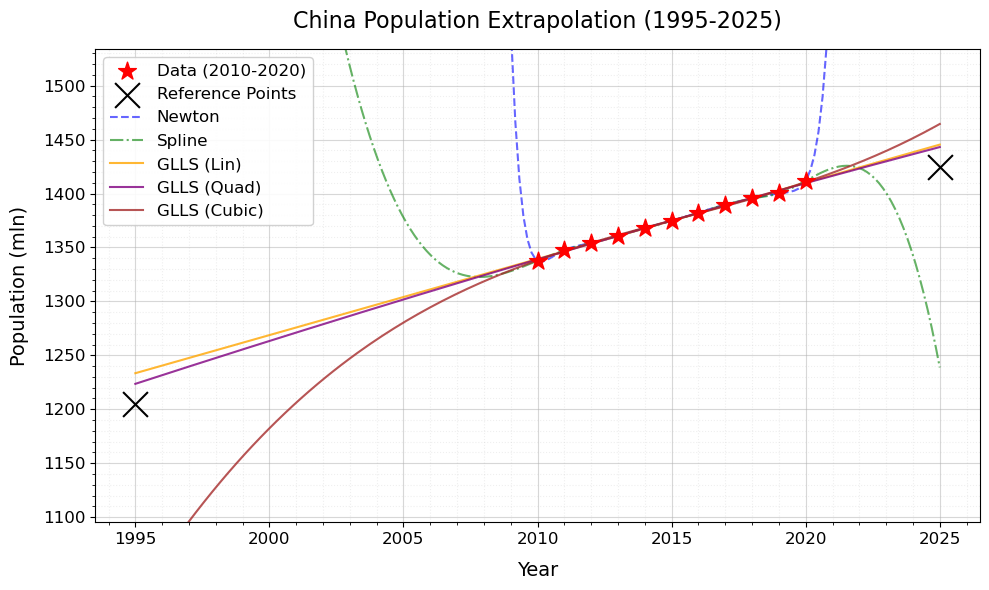

In [27]:
years_vec = np.array([2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020], dtype=float)
pop_china = np.array([1337.7, 1347.4, 1354.2, 1360.7, 1367.9, 1374.6, 1382.3, 1389.6, 1395.4, 1400.1, 1411.8], dtype=float)
targets = np.array([1995, 2025], dtype=float)
actuals_china = {1995: 1204.86, 2025: 1424.38}

analyze_country("China", years_vec, pop_china, targets, actuals_china)

# 6. India Analysis #


ANALYSIS: India

Year 1995.0:
  Actual/Projected: 960.30 mln
  Newton:   -27015536.40 mln
  Spline:   833.92 mln
  GLLS(1):  1013.49 mln
  GLLS(2):  989.04 mln
  GLLS(3):  1017.55 mln

Year 2025.0:
  Actual/Projected: 1454.61 mln
  Newton:   -15843.10 mln
  Spline:   1457.00 mln
  GLLS(1):  1448.16 mln
  GLLS(2):  1442.52 mln
  GLLS(3):  1439.45 mln
Plot saved to: india_population.pdf


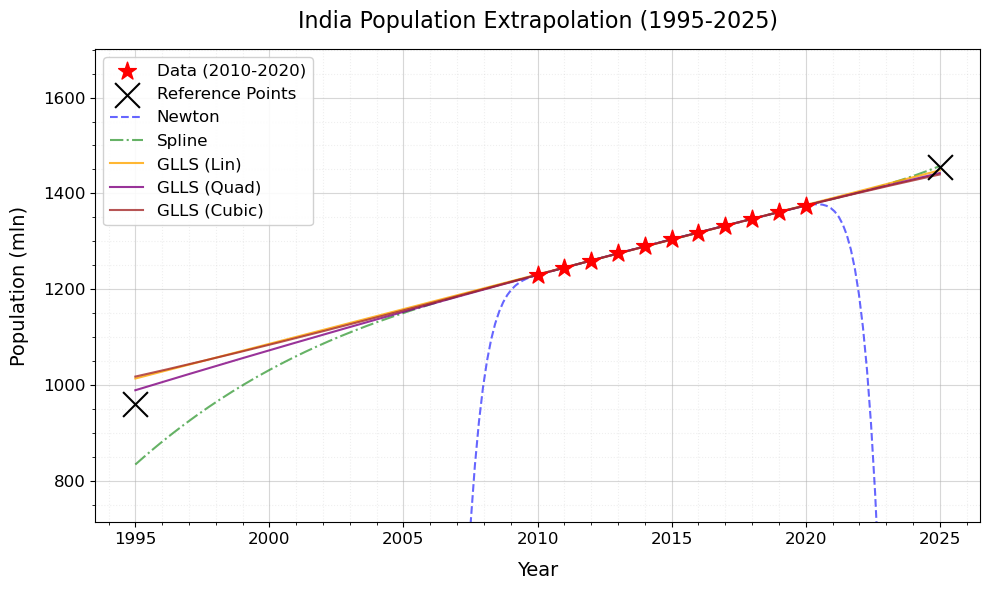

In [28]:
pop_india = np.array([1230.1, 1244.8, 1259.7, 1274.6, 1289.4, 1304.0, 1318.3, 1332.6, 1346.9, 1361.0, 1374.6], dtype=float)
actuals_india = {1995: 960.30, 2025: 1454.61}

analyze_country("India", years_vec, pop_india, targets, actuals_india)

# 7. Germany Analysis #


ANALYSIS: Germany

Year 1995.0:
  Actual/Projected: 81.66 mln
  Newton:   -15096609.94 mln
  Spline:   -29.75 mln
  GLLS(1):  74.65 mln
  GLLS(2):  75.49 mln
  GLLS(3):  150.28 mln

Year 2025.0:
  Actual/Projected: 83.20 mln
  Newton:   -169.82 mln
  Spline:   89.11 mln
  GLLS(1):  85.20 mln
  GLLS(2):  85.39 mln
  GLLS(3):  77.35 mln
Plot saved to: germany_population.pdf


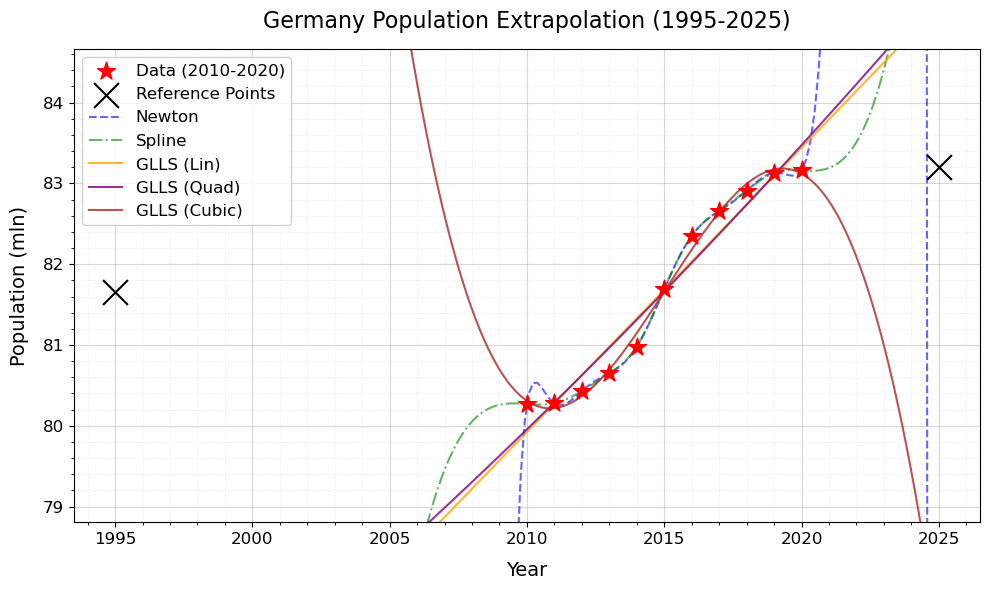

In [29]:
pop_germany = np.array([80.27, 80.28, 80.43, 80.65, 80.98, 81.69, 82.35, 82.66, 82.91, 83.13, 83.16], dtype=float)
actuals_germany = {1995: 81.66, 2025: 83.20}

analyze_country("Germany", years_vec, pop_germany, targets, actuals_germany)

# 8. Brazil Analysis #


ANALYSIS: Brazil

Year 1995.0:
  Actual/Projected: 161.74 mln
  Newton:   235133.60 mln
  Spline:   172.77 mln
  GLLS(1):  169.12 mln
  GLLS(2):  157.85 mln
  GLLS(3):  179.97 mln

Year 2025.0:
  Actual/Projected: 218.80 mln
  Newton:   2146.10 mln
  Spline:   224.34 mln
  GLLS(1):  221.37 mln
  GLLS(2):  218.77 mln
  GLLS(3):  216.39 mln
Plot saved to: brazil_population.pdf


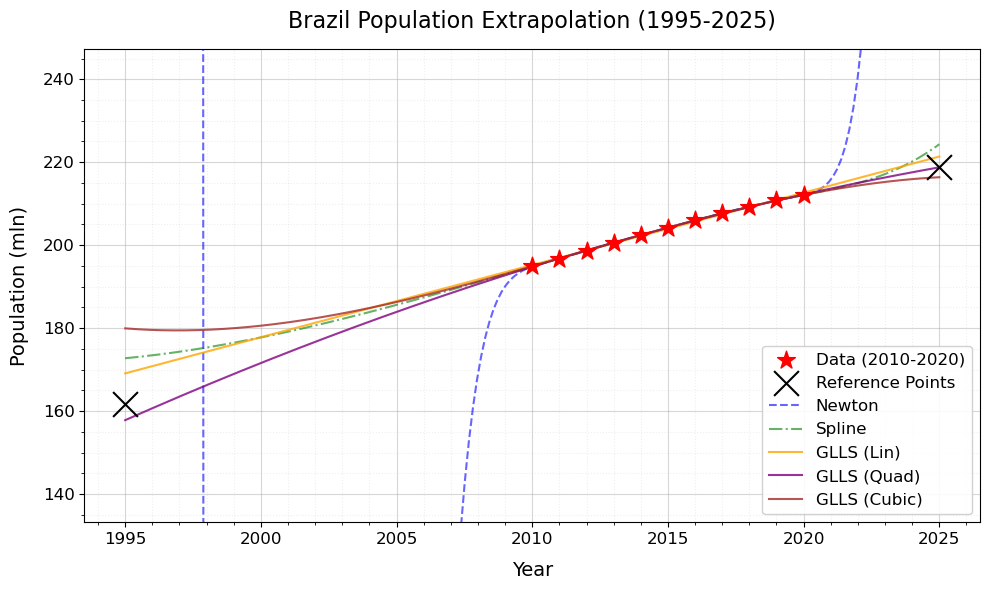

In [30]:
pop_brazil = np.array([194.9, 196.8, 198.7, 200.6, 202.4, 204.2, 206.0, 207.7, 209.3, 210.8, 212.1], dtype=float)
actuals_brazil = {1995: 161.74, 2025: 218.80}

analyze_country("Brazil", years_vec, pop_brazil, targets, actuals_brazil)

# 9. USA Analysis #


ANALYSIS: USA

Year 1995.0:
  Actual/Projected: 266.28 mln
  Newton:   55859072.00 mln
  Spline:   243.38 mln
  GLLS(1):  278.69 mln
  GLLS(2):  257.10 mln
  GLLS(3):  328.37 mln

Year 2025.0:
  Actual/Projected: 345.43 mln
  Newton:   32210.70 mln
  Spline:   342.23 mln
  GLLS(1):  341.01 mln
  GLLS(2):  336.03 mln
  GLLS(3):  328.36 mln
Plot saved to: usa_population.pdf


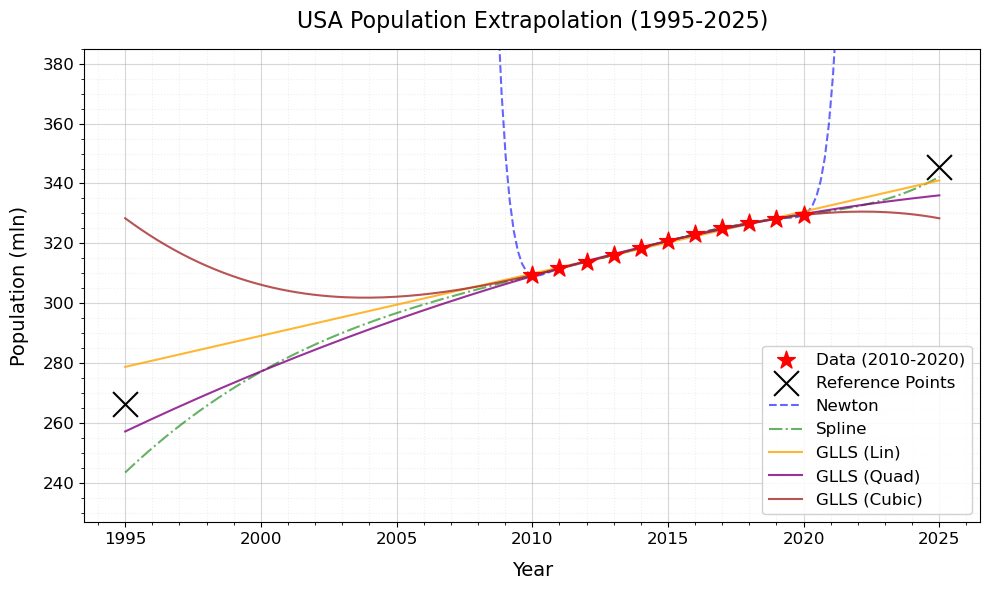

In [31]:
pop_usa = np.array([309.3, 311.6, 313.9, 316.1, 318.4, 320.7, 323.1, 325.1, 326.7, 328.2, 329.5], dtype=float)
actuals_usa = {1995: 266.28, 2025: 345.43}

analyze_country("USA", years_vec, pop_usa, targets, actuals_usa)

# 10. Japan Analysis #


ANALYSIS: Japan

Year 1995.0:
  Actual/Projected: 125.47 mln
  Newton:   79869243.60 mln
  Spline:   139.71 mln
  GLLS(1):  130.55 mln
  GLLS(2):  130.68 mln
  GLLS(3):  158.75 mln

Year 2025.0:
  Actual/Projected: 121.96 mln
  Newton:   47645.10 mln
  Spline:   129.35 mln
  GLLS(1):  125.39 mln
  GLLS(2):  125.42 mln
  GLLS(3):  122.40 mln
Plot saved to: japan_population.pdf


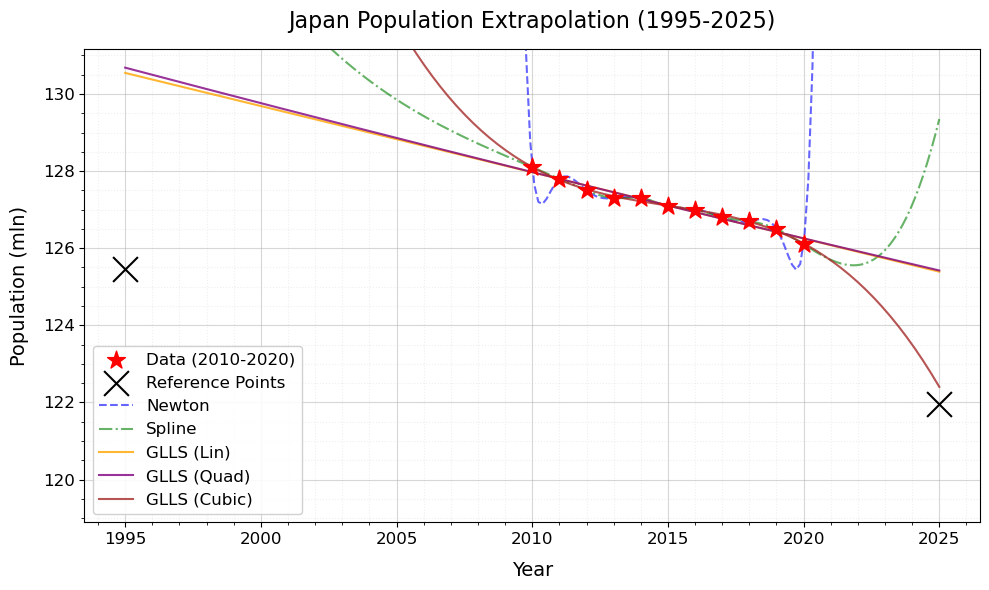

In [32]:
pop_japan = np.array([128.1, 127.8, 127.5, 127.3, 127.3, 127.1, 127.0, 126.8, 126.7, 126.5, 126.1], dtype=float)
actuals_japan = {1995: 125.47, 2025: 121.96}

analyze_country("Japan", years_vec, pop_japan, targets, actuals_japan)